____
# Gather drifter + alti + wind data

In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir
from swot import browse_swot_250m, add_mask_inside_swot, build_swath_polygon

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo

crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

___________
# CHOOSE

In [2]:
drifters_sources = "all_med_variational_10min_v0.nc"

# Drifters param
dt = "12h"
drifter_preprocess = "spectral_decomp"  # '', 'spectral_decomp', 'low_pass'
drifter_preprocess_param = "LF"  # spectral band

colocs_sources = f"{dt}_{drifter_preprocess}_" + drifters_sources
drifters_path = os.path.join(
    zarr_dir,
    "coloc_files",
    "drifters",
    f"drifterscoloc_" + colocs_sources.replace(".nc", ".csv"),
)

# Alti
product_key = "swot_2km"  #  'swot_2km', 'swot_250m', 'L4_global_noswot', 'L4_regional_noswot', 'L4_withnadirswot'
alti_diff_method = "diff_only"  #'diff_only', 'fitting_kernel', 'gaussian', 'fromduacsv'
alti_diff_method_param = ""  # {}, {'npts':5}, {'cutoff':5e3}
ggd_var = "etaf"  #'etaf', 'etac'

# Wind
product_key = "era5"
model = "rio"
wd_depth = "0"

In [3]:
def define_coloc_source(dt, drifter_preprocess="", drifter_preprocess_param=""):
    # default
    file_key, spectral_key = (
        "spectral_decomp",
        "",
    )  # spectral_decomp files contain original velocities/accelerations

    # assert
    assert drifter_preprocess in [
        "",
        "spectral_decomp",
        "low_pass",
    ], "drifter_preprocess should be in ['', 'spectral_decomp', 'low_pass']"

    # spectral decomp
    if drifter_preprocess == "spectral_decomp":
        assert drifter_preprocess_param in [
            "",
            "LF",
            "inertial",
            "diurnal",
            "semidiurnal",
            "HF",
        ], "drifter_preprocess_param while using spectral_decomp should be in  ['', 'LF', 'inertial', 'diurnal', 'semidiurnal', 'HF']"
        spectral_key = drifter_preprocess_param + "_"
        file_key = "spectral_decomp"

    # low pass
    if drifter_preprocess == "low_pass":
        cutoff = drifter_preprocess_param
        file_key = f"low_pass_{str(cutoff).replace('0.', '0')}"

    # find good file
    return f"{dt}_{file_key}_" + drifters_sources.replace(".nc", "")

In [4]:
dtypes = {"drifter_id": str, "drifter_type": str}


def prepared_drifters(dt, drifter_preprocess="", drifter_preprocess_param=""):

    colocs_sources = define_coloc_source(
        dt, drifter_preprocess, drifter_preprocess_param
    )
    drifters_path = os.path.join(
        zarr_dir, "coloc_files", "drifters", f"drifterscoloc_" + colocs_sources + ".csv"
    )

    if drifter_preprocess == "spectral_decomp":
        spectral_key = drifter_preprocess_param + "_"
    else:
        spectral_key = ""

    # Treat
    dfr = pd.read_csv(drifters_path, parse_dates=["datetime"], dtype=dtypes).set_index(
        "row_number"
    )
    dfr["time_to_swot"] = dfr.time_to_swot.astype("timedelta64[ns]")
    dfr["f"] = 2 * 2 * np.pi / 86164.1 * np.sin(dfr.latitude * np.pi / 180)
    dfr["core"] = -dfr.f * dfr[spectral_key + "velocity_north"]
    dfr["corn"] = dfr.f * dfr[spectral_key + "velocity_east"]
    dfr = dfr.rename(
        columns={
            spectral_key + "acceleration_north": "accn",
            spectral_key + "acceleration_east": "acce",
        }
    )
    return dfr[
        [
            "datetime",
            "longitude",
            "latitude",
            "pass_number",
            "time_to_swot",
            "cycle_number",
            "cycle_date",
            "drifter_id",
            "drifter_type",
            "accn",
            "acce",
            "core",
            "corn",
        ]
    ]


dfr = prepared_drifters(dt, "spectral_decomp", "LF")
dfr.dropna()

,datetime,longitude,latitude,pass_number,time_to_swot,cycle_number,cycle_date,drifter_id,drifter_type,accn,acce,core,corn
row_number,,,,,,,,,,,,,
0,2023-04-01 11:50:00,4.811970,42.220893,3,0 days 11:52:32.696536,478,2023-04-01 23:42:32.696536000,300534060315840,SVP,-0.000002,0.000004,-0.000008,0.000002
1,2023-04-01 12:00:00,4.812432,42.221430,3,0 days 11:42:32.696536,478,2023-04-01 23:42:32.696536000,300534060315840,SVP,-0.000002,0.000004,-0.000008,0.000002
2,2023-04-01 12:10:00,4.812916,42.221930,3,0 days 11:32:32.696536,478,2023-04-01 23:42:32.696536000,300534060315840,SVP,-0.000002,0.000004,-0.000008,0.000002
3,2023-04-01 12:20:00,4.813418,42.222394,3,0 days 11:22:32.696536,478,2023-04-01 23:42:32.696536000,300534060315840,SVP,-0.000002,0.000003,-0.000007,0.000002
4,2023-04-01 12:30:00,4.813933,42.222825,3,0 days 11:12:32.696536,478,2023-04-01 23:42:32.696536000,300534060315840,SVP,-0.000002,0.000003,-0.000007,0.000003
...,...,...,...,...,...,...,...,...,...,...,...,...,...
376718,2023-07-10 06:10:00,2.417786,39.788394,16,0 days 11:13:38.131544384,577,2023-07-09 18:56:21.868455616,300534060015760,SVP,0.000002,0.000002,-0.000017,0.000001
376719,2023-07-10 06:20:00,2.416881,39.788885,16,0 days 11:23:38.131544384,577,2023-07-09 18:56:21.868455616,300534060015760,SVP,0.000002,0.000002,-0.000018,0.000001
376720,2023-07-10 06:30:00,2.415948,39.789399,16,0 days 11:33:38.131544384,577,2023-07-09 18:56:21.868455616,300534060015760,SVP,0.000002,0.000002,-0.000018,0.000002


In [5]:
def prepared_alti(
    dt,
    drifter_preprocess="",
    drifter_preprocess_param="",
    alti_product_key="swot2km",
    alti_diff_method="diff_only",
    alti_diff_method_param="",
):

    colocs_sources = define_coloc_source(
        dt, drifter_preprocess, drifter_preprocess_param
    )

    # L4 products
    if "L4" in alti_product_key:
        dfs = pd.read_csv(
            os.path.join(
                zarr_dir,
                "coloc_files",
                "alti",
                "alticoloc_" + alti_product_key + "_" + colocs_sources + ".csv",
            )
        ).set_index("row_number")
        dfs["f"] = 2 * 2 * np.pi / 86164.1 * np.sin(dfs.latitude * np.pi / 180)
        dfs["ggde_fromduacsv"] = dfs.f * dfs.vgos
        dfs["ggdn_fromduacsv"] = -dfs.f * dfs.ugos
        l = ["ggde_fromduacsv", "ggdn_fromduacsv"]
        dfs = dfs[l]

    # L3 products
    else:
        # SSH
        if alti_diff_method_param != "":
            alti_diff_method_param = str(alti_diff_method_param) + "_"
        dfs = pd.read_csv(
            os.path.join(
                zarr_dir,
                "coloc_files",
                "alti",
                f"alticoloc_{alti_product_key}_{alti_diff_method}_{alti_diff_method_param}"
                + colocs_sources
                + ".csv",
            )
        ).set_index("row_number")

        # General
        dfg = pd.read_csv(
            os.path.join(
                zarr_dir,
                "coloc_files",
                "alti",
                f"alticoloc_{alti_product_key}_general_" + colocs_sources + ".csv",
            )
        ).set_index("row_number")
        dfg["f"] = 2 * 2 * np.pi / 86164.1 * np.sin(dfs.latitude * np.pi / 180)

        dfs = pd.concat([dfg, dfs], axis=1)

        # from duacs
        dfs = dfs.copy()  # defragmented
        dfs["ggde_fromduacsv"] = dfs.f * dfs.duacs_speed_meridional_abs
        dfs["ggdn_fromduacsv"] = -dfs.f * dfs.duacs_speed_zonal_abs

        ggd_var = [v for v in dfs.columns if ("etaf" in v) | ("etac" in v)]
        # rotate and compute quantities
        for v in ggd_var:
            g = 9.81
            from swot import rotate

            dfs["ggde_" + v] = g * rotate(dfs["dx_" + v], dfs["dy_" + v], dfs["phi"])[0]
            dfs["ggdn_" + v] = g * rotate(dfs["dx_" + v], dfs["dy_" + v], dfs["phi"])[1]
            dfs["vorticity_" + v] = g * (dfs["dxx_" + v] + dfs["dyy_" + v]) / dfs.f**2
            dfs["strain_s_" + v] = g * (dfs["dxx_" + v] - dfs["dyy_" + v]) / dfs.f**2
            dfs["strain_n_" + v] = (
                -2 * g * (dfs["dxy_" + v] - dfs["dxy_" + v]) / dfs.f**2
            )

        l = (
            ["ggde_" + v for v in ggd_var]
            + ["ggdn_" + v for v in ggd_var]
            + ["vorticity_" + v for v in ggd_var]
            + ["strain_s_" + v for v in ggd_var]
            + ["strain_n_" + v for v in ggd_var]
            + ["ggde_fromduacsv", "ggdn_fromduacsv", "phi"]
        )

        dfs = dfs[l]

    return (
        dfs.sort_index()
    )  # .rename(columns ={v : v+'_' +alti_product_key for v in dfs})


dfa = prepared_alti(
    dt,
    drifter_preprocess="",
    drifter_preprocess_param="",
    alti_product_key="swot2km",
    alti_diff_method="fitting_kernel",
    alti_diff_method_param=int(5),
)
dfa.dropna()

,ggde_etaf,ggde_etac,ggdn_etaf,ggdn_etac,vorticity_etaf,vorticity_etac,strain_s_etaf,strain_s_etac,strain_n_etaf,strain_n_etac,ggde_fromduacsv,ggdn_fromduacsv,phi
row_number,,,,,,,,,,,,,
0,0.000002,-0.000008,0.000015,0.000022,-0.099829,0.025006,0.082218,0.326448,-0.0,-0.0,0.000005,0.000006,0.238874
1,0.000002,-0.000007,0.000015,0.000023,-0.102017,0.011453,0.087445,0.333600,-0.0,-0.0,0.000005,0.000006,0.238895
2,0.000002,-0.000007,0.000015,0.000023,-0.103193,0.004073,0.088883,0.339722,-0.0,-0.0,0.000005,0.000005,0.238897
3,0.000002,-0.000007,0.000015,0.000024,-0.104384,-0.003413,0.090430,0.346442,-0.0,-0.0,0.000005,0.000005,0.238899
4,0.000001,-0.000007,0.000015,0.000024,-0.105587,-0.010972,0.092073,0.353707,-0.0,-0.0,0.000005,0.000005,0.238902
...,...,...,...,...,...,...,...,...,...,...,...,...,...
376574,-0.000002,0.000004,-0.000043,-0.000055,-0.277786,-0.413997,0.370804,0.640158,-0.0,-0.0,0.000009,-0.000020,2.911936
376575,-0.000002,0.000004,-0.000043,-0.000054,-0.284928,-0.422076,0.371376,0.623162,-0.0,-0.0,0.000009,-0.000020,2.911961
376576,-0.000002,0.000004,-0.000043,-0.000053,-0.288241,-0.425728,0.373751,0.621934,-0.0,-0.0,0.000009,-0.000019,2.911966


In [6]:
def prepared_wd(
    dt,
    drifter_preprocess="",
    drifter_preprocess_param="",
    wd_product_key="era5",
    wd_model="rio",
):

    colocs_source = define_coloc_source(
        dt, drifter_preprocess, drifter_preprocess_param
    )
    if wd_model in "rioagesc":
        wd_model = "rioagesc"  # both in one file
    dfw = pd.read_csv(
        os.path.join(
            zarr_dir,
            "coloc_files",
            "wind",
            f"{wd_product_key}_{wd_model}_" + colocs_source.replace(".nc", "") + ".csv",
        )
    ).set_index("row_number")
    dfw = dfw[[v for v in dfw if ("vsde" in v or "vsdn" in v)]]
    return dfw  # .rename(columns ={v : v+'_' +wd_key for v in dfw})


dfw = prepared_wd(
    dt,
    drifter_preprocess="",
    drifter_preprocess_param="",
    wd_product_key="era5",
    wd_model="rioagesc",
)
dfw.dropna()

,vsde_agesc_z15,vsdn_agesc_z15,vsde_rio_z15,vsdn_rio_z15,vsde_rioold_z15,vsdn_rioold_z15,vsde_agesc_z0,vsdn_agesc_z0,vsde_rio_z0,vsdn_rio_z0,vsde_rioold_z0,vsdn_rioold_z0
row_number,,,,,,,,,,,,
0,3.472544e-06,1.425954e-05,-8.526146e-06,1.827490e-06,-3.642704e-06,-8.344444e-07,-1.412589e-05,0.000016,-2.569273e-05,-0.000008,-1.321045e-05,-0.000007
1,3.314936e-06,1.391880e-05,-8.299754e-06,1.699292e-06,-3.531550e-06,-8.432340e-07,-1.394843e-05,0.000016,-2.488993e-05,-0.000008,-1.277188e-05,-0.000007
2,3.217773e-06,1.348894e-05,-7.961506e-06,1.578418e-06,-3.378275e-06,-8.289194e-07,-1.351111e-05,0.000015,-2.379743e-05,-0.000008,-1.219449e-05,-0.000007
3,3.120458e-06,1.305961e-05,-7.623353e-06,1.457798e-06,-3.225084e-06,-8.145234e-07,-1.307484e-05,0.000015,-2.270557e-05,-0.000008,-1.161751e-05,-0.000006
4,3.022959e-06,1.263080e-05,-7.285332e-06,1.337421e-06,-3.071988e-06,-8.000567e-07,-1.263969e-05,0.000014,-2.161443e-05,-0.000007,-1.104097e-05,-0.000006
...,...,...,...,...,...,...,...,...,...,...,...,...
376574,4.020864e-07,9.195299e-07,4.815808e-07,7.428767e-07,5.250306e-08,3.757713e-07,-1.039533e-06,0.000003,1.705300e-07,0.000003,-1.861708e-07,0.000002
376575,3.830223e-07,8.627292e-07,4.931299e-07,6.937847e-07,6.588060e-08,3.587949e-07,-9.459813e-07,0.000003,2.758919e-07,0.000003,-1.169087e-07,0.000001
376576,3.641129e-07,8.061436e-07,5.047429e-07,6.450343e-07,7.922107e-08,3.419628e-07,-8.526801e-07,0.000002,3.809084e-07,0.000002,-4.793918e-08,0.000001


In [9]:
comb = dict(
    dt="12h",
    drifter_preprocess="",
    drifter_preprocess_param="",
    alti_product_key="swot2km",
    alti_diff_method="diff_only",
    alti_diff_method_param="",
    ggd_var="etaf",
    wd_product_key="era5",
    wd_model="rio",
    wd_depth="0",
)

In [10]:
from cstes import surface_drifters, depth_drifters, depth_50, depth_100


def create_id_comb(
    dt,
    drifter_preprocess,
    drifter_preprocess_param,
    alti_product_key,
    alti_diff_method,
    alti_diff_method_param,
    ggd_var,
    wd_product_key,
    wd_model,
    wd_depth,
):

    # For coherence
    if "L4" in alti_product_key:
        alti_diff_method = "fromduacsv"
        alti_diff_method_param = ""
        ggd_var = "fromduacsv"

    else:
        l = ["ggde_" + ggd_var, "ggdn_" + ggd_var, "phi"]

    if ggd_var == "fromduacsv":
        alti_diff_method = "fromduacsv"
        alti_diff_method_param = ""

    colocs_source = define_coloc_source(
        dt, drifter_preprocess, drifter_preprocess_param
    )
    return f"{colocs_source}__{drifter_preprocess_param}__{alti_product_key}_{alti_diff_method}_{alti_diff_method_param}_{ggd_var}__{wd_product_key}_{wd_model}{wd_depth}"


def select_nearest_swot_coloc(df):
    idx = df.groupby(
        ["pass_number", "cycle_number", "drifter_id"]
    ).time_to_swot.idxmin()
    return df.loc[idx]


def one_comb(
    dt,
    drifter_preprocess,
    drifter_preprocess_param,
    alti_product_key,
    alti_diff_method,
    alti_diff_method_param,
    ggd_var,
    wd_product_key,
    wd_model,
    wd_depth,
):

    id_comb = create_id_comb(
        dt,
        drifter_preprocess,
        drifter_preprocess_param,
        alti_product_key,
        alti_diff_method,
        alti_diff_method_param,
        ggd_var,
        wd_product_key,
        wd_model,
        wd_depth,
    )

    # For coherence
    if "L4" in alti_product_key:
        alti_diff_method = "fromduacsv"
        alti_diff_method_param = ""
        ggd_var = "fromduacsv"
        print("only 'fromduacsv' method is available for L4")
        l = ["ggde_" + ggd_var, "ggdn_" + ggd_var]

    else:
        l = ["ggde_" + ggd_var, "ggdn_" + ggd_var, "phi"]

    if ggd_var == "fromduacsv":
        alti_diff_method = "fromduacsv"
        alti_diff_method_param = ""

    df = pd.concat(
        [
            prepared_drifters(dt, drifter_preprocess, drifter_preprocess_param),
            prepared_alti(
                dt,
                drifter_preprocess,
                drifter_preprocess_param,
                alti_product_key,
                alti_diff_method,
                alti_diff_method_param,
            )[l].rename(columns={"ggde_" + ggd_var: "ggde", "ggdn_" + ggd_var: "ggdn"}),
            prepared_wd(
                dt,
                drifter_preprocess,
                drifter_preprocess_param,
                wd_product_key,
                wd_model,
            )[
                [
                    "vsde_" + wd_model + "_z" + wd_depth,
                    "vsdn_" + wd_model + "_z" + wd_depth,
                ]
            ].rename(
                columns={
                    "vsde_" + wd_model + "_z" + wd_depth: "wde",
                    "vsdn_" + wd_model + "_z" + wd_depth: "wdn",
                }
            ),
        ],
        axis=1,
    ).dropna()  # with dropna, depends on the altimetry filter
    print(len(df))

    if "phi" not in df.columns:
        df["phi"] = np.zeros(len(df))

    # depth
    depth = df["pass_number"].copy()
    depth.loc[df["drifter_type"].isin(surface_drifters)] = 0
    depth.loc[df["drifter_type"].isin(depth_drifters)] = 15
    depth.loc[df["drifter_id"].isin(depth_50)] = 50
    depth.loc[df["drifter_id"].isin(depth_100)] = 100

    df["depth"] = depth
    print(id_comb)

    return df, id_comb


def dataset_coloc_combs(comb_list, nearest=False, remove_id_outliers=True):
    D = []
    for comb in comb_list:
        df, id_comb = one_comb(**comb)

        # remove identified swot outliers
        if remove_id_outliers:
            from cstes import remove_pb_swot

            df = remove_pb_swot(df)

        if nearest:
            # select only nearest in time colocalisation
            df = select_nearest_swot_coloc(df)  # .dropna()

        coords_list = [
            "datetime",
            "longitude",
            "latitude",
            "pass_number",
            "time_to_swot",
            "cycle_number",
            "drifter_id",
            "drifter_type",
            "depth",
            "phi",
        ]

        ds = df[coords_list].to_xarray()
        ds["id_comb"] = id_comb

        for direction in ["e", "n"]:
            if direction == "e":
                l = {"acc": "acce", "cor": "core", "ggd": "ggde", "wd": "wde"}
            if direction == "n":
                l = {"acc": "accn", "cor": "corn", "ggd": "ggdn", "wd": "wdn"}

            # sum
            ds["sum" + direction] = sum([df[l[v]] for v in l])

            # simple var + sum- one term
            for v in l:
                ds[l[v]] = df[l[v]]
                ds["exc" + direction + "_" + v] = ds["sum" + direction] - ds[l[v]]

            # 2 by 2 product
            import itertools

            couple = list(itertools.combinations(list(l.keys()), 2))
            for c in couple:
                ds["prod" + direction + "_" + "_".join(c)] = (
                    ds[c[0] + direction] * ds[c[1] + direction]
                )

        D.append(ds.set_coords("id_comb"))
    ds = xr.concat(D, dim="id_comb").set_coords(coords_list)

    # remove identified swot outliers
    if remove_id_outliers:
        from cstes import err_acc

        err_acc_update = np.array(err_acc)[np.isin(err_acc, ds.row_number)]
        ds = ds.drop_sel(row_number=err_acc_update)
        print("Identified SWOT and drifter outliers have been removed")

    return ds

In [11]:
df0, id_comb0 = one_comb(**comb)

300813
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_diff_only__etaf__era5_rio0


In [12]:
df0

,datetime,longitude,latitude,pass_number,time_to_swot,cycle_number,cycle_date,drifter_id,drifter_type,accn,acce,core,corn,ggde,ggdn,phi,wde,wdn,depth
row_number,,,,,,,,,,,,,,,,,,,
0,2023-04-01 11:50:00,4.811970,42.220893,3,0 days 11:52:32.696536,478,2023-04-01 23:42:32.696536000,300534060315840,SVP,-0.000012,0.000006,-0.000010,0.000006,0.000004,0.000011,0.238874,-2.569273e-05,-0.000008,15
1,2023-04-01 12:00:00,4.812432,42.221430,3,0 days 11:42:32.696536,478,2023-04-01 23:42:32.696536000,300534060315840,SVP,-0.000012,0.000005,-0.000009,0.000007,0.000004,0.000010,0.238895,-2.488993e-05,-0.000008,15
2,2023-04-01 12:10:00,4.812916,42.221930,3,0 days 11:32:32.696536,478,2023-04-01 23:42:32.696536000,300534060315840,SVP,-0.000011,0.000004,-0.000009,0.000007,0.000004,0.000010,0.238897,-2.379743e-05,-0.000008,15
3,2023-04-01 12:20:00,4.813418,42.222394,3,0 days 11:22:32.696536,478,2023-04-01 23:42:32.696536000,300534060315840,SVP,-0.000010,0.000003,-0.000008,0.000007,0.000004,0.000010,0.238899,-2.270557e-05,-0.000008,15
4,2023-04-01 12:30:00,4.813933,42.222825,3,0 days 11:12:32.696536,478,2023-04-01 23:42:32.696536000,300534060315840,SVP,-0.000009,0.000002,-0.000007,0.000007,0.000004,0.000010,0.238902,-2.161443e-05,-0.000007,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
376718,2023-07-10 06:10:00,2.417786,39.788394,16,0 days 11:13:38.131544384,577,2023-07-09 18:56:21.868455616,300534060015760,SVP,0.000006,-0.000009,-0.000009,-0.000012,0.000007,-0.000024,2.916795,7.387227e-07,0.000006,15
376719,2023-07-10 06:20:00,2.416881,39.788885,16,0 days 11:23:38.131544384,577,2023-07-09 18:56:21.868455616,300534060015760,SVP,0.000007,-0.000007,-0.000009,-0.000012,0.000007,-0.000024,2.916788,7.636069e-07,0.000006,15
376720,2023-07-10 06:30:00,2.415948,39.789399,16,0 days 11:33:38.131544384,577,2023-07-09 18:56:21.868455616,300534060015760,SVP,0.000008,-0.000005,-0.000009,-0.000012,0.000008,-0.000024,2.916780,7.893526e-07,0.000006,15


In [13]:
comb_list = [
    dict(
        dt="12h",
        drifter_preprocess="",
        drifter_preprocess_param="LF",
        alti_product_key="swot250m",
        alti_diff_method="diff_only",
        alti_diff_method_param="",
        ggd_var="etaf",
        wd_product_key="era5",
        wd_model="rio",
        wd_depth="0",
    ),
    dict(
        dt="12h",
        drifter_preprocess="",
        drifter_preprocess_param="",
        alti_product_key="L4_noswot_regional",
        alti_diff_method="fitting_kernel",
        alti_diff_method_param=5,
        ggd_var="etaf",
        wd_product_key="era5",
        wd_model="rio",
        wd_depth="0",
    ),
    dict(
        dt="12h",
        drifter_preprocess="",
        drifter_preprocess_param="",
        alti_product_key="swot2km",
        alti_diff_method="diff_only",
        alti_diff_method_param="",
        ggd_var="etaf",
        wd_product_key="era5",
        wd_model="rio",
        wd_depth="0",
    ),
]
ds = dataset_coloc_combs(comb_list, nearest=False, remove_id_outliers=True)

In [14]:
ds = dataset_coloc_combs(comb_list, nearest=False, remove_id_outliers=True)

357404
12h_spectral_decomp_all_med_variational_10min_v0__LF__swot250m_diff_only__etaf__era5_rio0
only 'fromduacsv' method is available for L4
365891
12h_spectral_decomp_all_med_variational_10min_v0____L4_noswot_regional_fromduacsv__fromduacsv__era5_rio0
300813
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_diff_only__etaf__era5_rio0
Identified SWOT and drifter outliers have been removed


In [15]:
ds

<xarray.Dataset> Size: 361MB
Dimensions:        (id_comb: 3, row_number: 373207)
Coordinates:
    datetime       (id_comb, row_number) datetime64[ns] 9MB 2023-04-01T11:50:...
    longitude      (id_comb, row_number) float64 9MB 4.812 4.812 ... 2.415 2.414
    latitude       (id_comb, row_number) float64 9MB 42.22 42.22 ... 39.79 39.79
    pass_number    (id_comb, row_number) float64 9MB 3.0 3.0 3.0 ... 16.0 16.0
    time_to_swot   (id_comb, row_number) timedelta64[ns] 9MB 11:52:32.696536 ...
    cycle_number   (id_comb, row_number) float64 9MB 478.0 478.0 ... 577.0 577.0
    drifter_id     (id_comb, row_number) object 9MB '300534060315840' ... '30...
    drifter_type   (id_comb, row_number) object 9MB 'SVP' 'SVP' ... 'SVP' 'SVP'
    depth          (id_comb, row_number) float64 9MB 15.0 15.0 ... 15.0 15.0
    phi            (id_comb, row_number) float64 9MB 0.2354 0.237 ... 2.917
  * row_number     (row_number) int64 3MB 0 1 2 3 ... 376720 376721 376722
  * id_comb        (id_comb) <U104 1kB '12h_spectral_decomp_all_med_variation...
Data variables: (12/30)
    sume           (id_comb, row_number) float64 9MB -1.804e-05 ... -2.701e-06
    acce           (id_comb, row_number) float64 9MB 6.386e-06 ... -1.995e-06
    exce_acc       (id_comb, row_number) float64 9MB -2.442e-05 ... -7.068e-07
    core           (id_comb, row_number) float64 9MB -1.001e-05 ... -1.024e-05
    exce_cor       (id_comb, row_number) float64 9MB -8.022e-06 ... 7.541e-06
    ggde           (id_comb, row_number) float64 9MB 1.129e-05 ... 8.692e-06
    ...             ...
    prodn_acc_cor  (id_comb, row_number) float64 9MB -7.476e-11 ... -1.039e-10
    prodn_acc_ggd  (id_comb, row_number) float64 9MB -3.574e-10 ... -1.942e-10
    prodn_acc_wd   (id_comb, row_number) float64 9MB 9.676e-11 ... 4.653e-11
    prodn_cor_ggd  (id_comb, row_number) float64 9MB 1.823e-10 ... 3.053e-10
    prodn_cor_wd   (id_comb, row_number) float64 9MB -4.934e-11 ... -7.314e-11
    prodn_ggd_wd   (id_comb, row_number) float64 9MB -2.359e-10 ... -1.368e-10

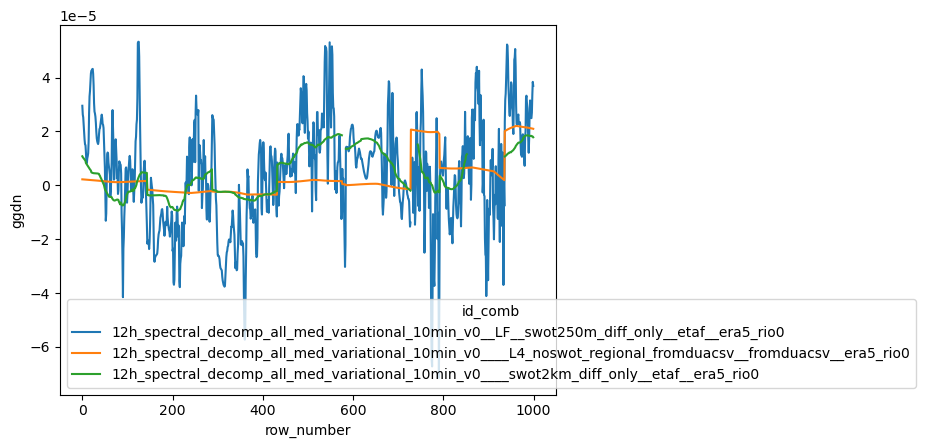

In [16]:
ds.ggdn.isel(row_number=slice(0, 1000)).plot(hue="id_comb")